# Delta策略模块演示

这个notebook演示如何使用delta模块进行策略研究和回测。

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('/home/jovyan/base_demo')
import base_tool

import pandas as pd
pd.set_option('display.max_rows', 15)
pd.set_option('display.max_columns', 65)

## 导入delta模块

In [3]:
import sys
sys.path.append('/home/jovyan/work/tactics_demo')
from delta import *

## 设置参数

In [5]:
instrument_id = '518880'
trade_ymd = '20260319'

param_dict = {
    'instrument_id': instrument_id,
    'trade_ymd': trade_ymd,
    'short_window': 60,
    'long_window': 300,
    'open_threshold': 2,
    'confidence_threshold': 0.4,
    'name': 'delta_v1',
    'trailing_stop_pct': 0.001,
    'y_window': 300,
    'stride': 1,
    'k_up': 3,
    'k_down': 3
}
param_dict['x_window'] = max(param_dict['short_window'], param_dict['long_window'])

## 获取交易日数据

In [6]:
trade_dates = get_trade_dates()
print(f"总交易日数量: {len(trade_dates)}")
print(f"交易日范围: {trade_dates[0]} ~ {trade_dates[-1]}")

train_dates, valid_dates, test_dates = split_dates(trade_dates)

总交易日数量: 54
交易日范围: 20260105 ~ 20260327
训练集: 20260105 ~ 20260302 (35天)
验证集: 20260303 ~ 20260313 (9天)
测试集: 20260316 ~ 20260327 (10天)


## 生成训练数据

In [7]:
print("生成训练集样本...")
X_train, y_train = samples_from_dates(train_dates, instrument_id, param_dict, create_feature, create_y)
print(f"训练集样本: X={X_train.shape}, y={y_train.shape}")
if len(y_train) > 0:
    print(f"标签分布:\n{y_train.value_counts()}")

生成训练集样本...
20260105: 产生 781 个样本
20260106: 产生 767 个样本
20260107: 产生 798 个样本
20260108: 产生 819 个样本
20260109: 产生 755 个样本
20260112: 产生 754 个样本
20260113: 产生 779 个样本
20260114: 产生 812 个样本
20260115: 产生 789 个样本
20260116: 产生 753 个样本
20260119: 产生 752 个样本
20260120: 产生 810 个样本
20260121: 产生 794 个样本
20260122: 产生 748 个样本
20260123: 产生 781 个样本
20260126: 产生 858 个样本
20260127: 产生 791 个样本
20260128: 产生 802 个样本
20260129: 产生 812 个样本
20260130: 产生 884 个样本
20260202: 产生 757 个样本
20260203: 产生 833 个样本
20260204: 产生 812 个样本
20260205: 产生 834 个样本
20260206: 产生 839 个样本
20260209: 产生 814 个样本
20260210: 产生 781 个样本
20260211: 产生 745 个样本
20260212: 产生 737 个样本
20260213: 产生 772 个样本
20260224: 产生 752 个样本
20260225: 产生 777 个样本
20260226: 产生 774 个样本
20260227: 产生 745 个样本
20260302: 产生 821 个样本
训练集样本: X=(27632, 11), y=(27632,)
标签分布:
0    19665
1     7967
Name: count, dtype: int64


In [8]:
print("生成验证集样本...")
X_valid, y_valid = samples_from_dates(valid_dates, instrument_id, param_dict, create_feature, create_y)
print(f"验证集样本: X={X_valid.shape}, y={y_valid.shape}")
if len(y_valid) > 0:
    print(f"标签分布:\n{y_valid.value_counts()}")

生成验证集样本...
20260303: 产生 794 个样本
20260304: 产生 886 个样本
20260305: 产生 807 个样本
20260306: 产生 780 个样本
20260309: 产生 804 个样本
20260310: 产生 783 个样本
20260311: 产生 763 个样本
20260312: 产生 759 个样本
20260313: 产生 750 个样本
验证集样本: X=(7126, 11), y=(7126,)
标签分布:
0    4995
1    2131
Name: count, dtype: int64


## 训练模型

In [10]:
model = train_model(X_train, y_train, X_valid, y_valid, param_dict)

[0]	validation_0-logloss:0.69260
[1]	validation_0-logloss:0.69203
[2]	validation_0-logloss:0.69145
[3]	validation_0-logloss:0.69151
[4]	validation_0-logloss:0.69082
[5]	validation_0-logloss:0.69085
[6]	validation_0-logloss:0.69059


[7]	validation_0-logloss:0.69005
[8]	validation_0-logloss:0.68942
[9]	validation_0-logloss:0.68917
[10]	validation_0-logloss:0.68900
[11]	validation_0-logloss:0.68903
[12]	validation_0-logloss:0.68916
[13]	validation_0-logloss:0.68854
[14]	validation_0-logloss:0.68806
[15]	validation_0-logloss:0.68819
[16]	validation_0-logloss:0.68762
[17]	validation_0-logloss:0.68718
[18]	validation_0-logloss:0.68705
[19]	validation_0-logloss:0.68662
[20]	validation_0-logloss:0.68657
[21]	validation_0-logloss:0.68612
[22]	validation_0-logloss:0.68572
[23]	validation_0-logloss:0.68519
[24]	validation_0-logloss:0.68469
[25]	validation_0-logloss:0.68422
[26]	validation_0-logloss:0.68384
[27]	validation_0-logloss:0.68388
[28]	validation_0-logloss:0.68350
[29]	validation_0-logloss:0.68355
[30]	validation_0-logloss:0.68312
[31]	validation_0-logloss:0.68263
[32]	validation_0-logloss:0.68229
[33]	validation_0-logloss:0.68220
[34]	validation_0-logloss:0.68221
[35]	validation_0-logloss:0.68186
[36]	validation_0

## 测试模型

In [11]:
print("生成测试集样本...")
X_test, y_test = samples_from_dates(test_dates, instrument_id, param_dict, create_feature, create_y)
print(f"测试集样本: X={X_test.shape}, y={y_test.shape}")
if len(y_test) > 0:
    print(f"标签分布:\n{y_test.value_counts()}")

accuracy = evaluate_model(model, X_test, y_test)

生成测试集样本...
20260316: 产生 755 个样本
20260317: 产生 762 个样本
20260318: 产生 795 个样本
20260319: 产生 792 个样本
20260320: 产生 815 个样本
20260323: 产生 844 个样本
20260324: 产生 842 个样本
20260325: 产生 783 个样本
20260326: 产生 862 个样本
20260327: 产生 787 个样本
测试集样本: X=(8037, 11), y=(8037,)
标签分布:
0    5659
1    2378
Name: count, dtype: int64
测试集准确率: 0.6674

分类报告:
              precision    recall  f1-score   support

           0       0.76      0.78      0.77      5659
           1       0.43      0.40      0.42      2378

    accuracy                           0.67      8037
   macro avg       0.59      0.59      0.59      8037
weighted avg       0.66      0.67      0.66      8037



## 保存模型

In [15]:
import os
model_filename = f"models/delta_model_{instrument_id}.joblib"
os.makedirs(os.path.dirname(model_filename), exist_ok=True)
save_model(model, model_filename)

模型已保存到: models/delta_model_518880.joblib


## 创建策略实例

In [16]:
strategy = StrategyDemo(model, param_dict)
print(f"策略已创建: {strategy.name}")

策略已创建: delta_v1


## 使用backtesting工具进行回测

In [17]:
import sys
sys.path.append('/home/jovyan/work/tactics_demo/tools')
from backtesting import backtest_multi_days, backtest_summary

result_df = backtest_multi_days(
    instrument_id=instrument_id,
    start_ymd='20260303',
    end_ymd='20260327',
    strategy=strategy,
    param_dict=param_dict
)

summary = backtest_summary(result_df)
print(summary)

日期 20260303 完成，盈亏: 11.30, 成交: 46次


KeyboardInterrupt: 

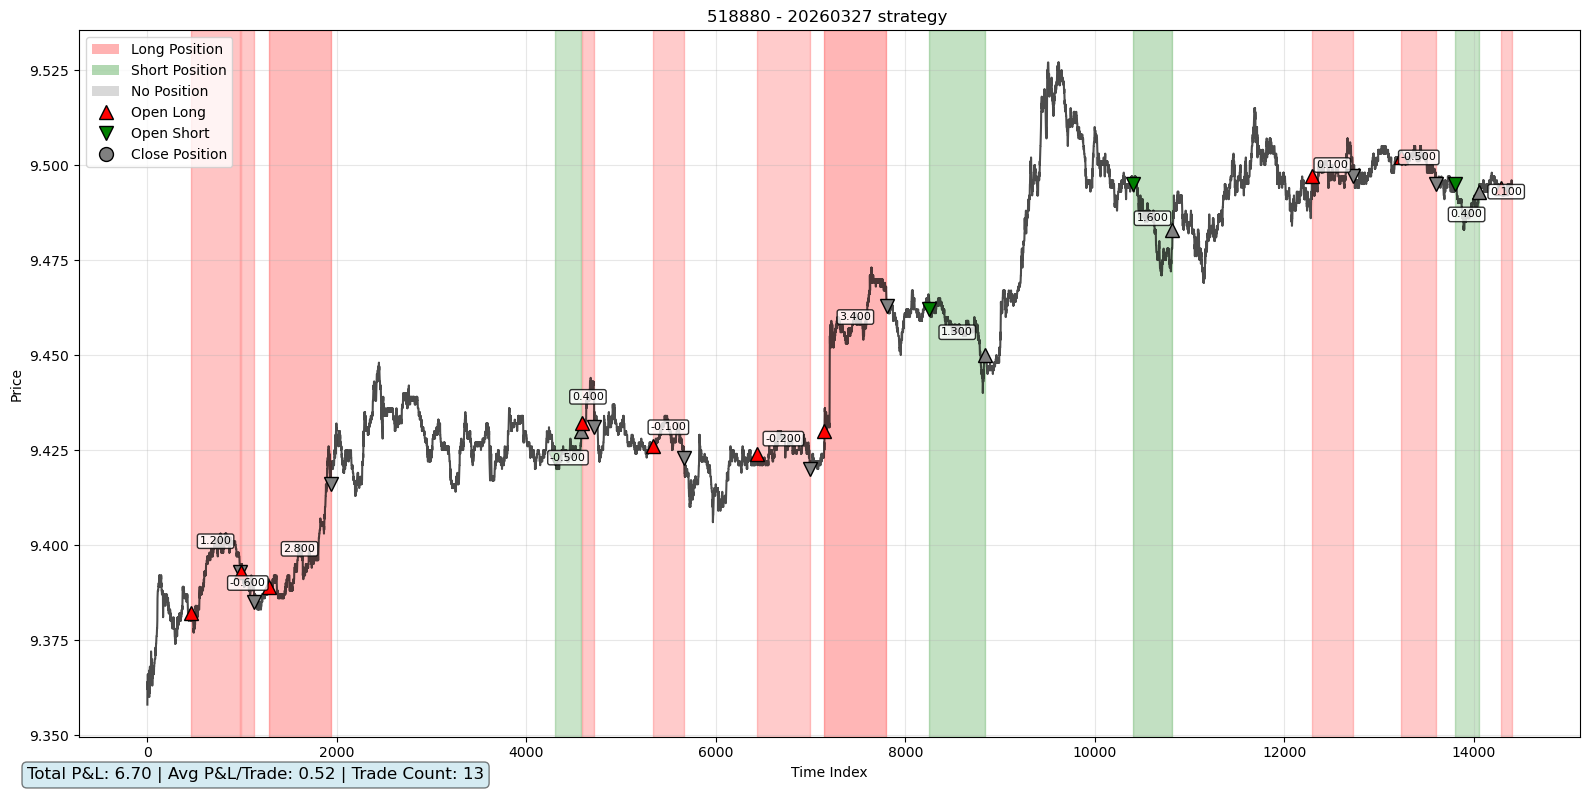

In [19]:
from single_day_backtest import single_day_backtest
hh = single_day_backtest(instrument_id,'20260327',strategy)